# PARAMETROS PARA OPTIMIZAR LA REGRESIÓN LOGISTICA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
cols = ['pclass','sex','age','fare']
df = df[cols + ['survived']].dropna()
df

,pclass,sex,age,fare,survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0
...,...,...,...,...,...
885,3,female,39.0,29.1250,0
886,2,male,27.0,13.0000,0
887,1,female,19.0,30.0000,1
889,1,male,26.0,30.0000,1


In [4]:
df['sex'] = df['sex'].map({'male':0, 'female':1})
df

,pclass,sex,age,fare,survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0
...,...,...,...,...,...
885,3,1,39.0,29.1250,0
886,2,0,27.0,13.0000,0
887,1,1,19.0,30.0000,1
889,1,0,26.0,30.0000,1


# CORRELACIONES

In [5]:
corr_matrix = df.corr()
corr_result = corr_matrix['survived']
corr_result.sort_values(ascending=False)

,survived
survived,1.000000
sex,0.538826
fare,0.268189
age,-0.077221
pclass,-0.359653


<Axes: >

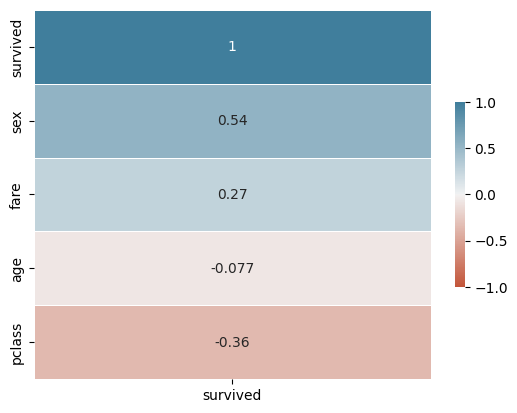

In [6]:
sns.heatmap(
    data=corr_result.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [7]:
X = df[cols]
y = df['survived']

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ENTRENAMIENTO SIN PARAMETROS

In [10]:
model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy}')

Accuracy : 0.7412587412587412


# PARAMETROS MAS COMUNES PARA OPTIMIZAR EL MODELO DE REGRESIÓN LOGISTICA


# SOLVER
El solver es el algoritmo que scikit-learn usa para optimizar los coeficientes de la regresión logística. Diferentes solvers funcionan mejor en diferentes escenarios, dependiendo del tamaño del dataset y si los datos son escasos o densos.
*   lbfgs(default) datos pequeños o medianos
*   liblinear : datos pequeños ideal para regresión logistica binaria.
*   newton-cg : datos medianos a grandes
*   saga  : datos grandes

In [11]:
model2 = LogisticRegression(solver='liblinear')
model2.fit(X_train,y_train)

y_pred2 = model2.predict(X_test)

accuracy = accuracy_score(y_test,y_pred2)
print(f'Accuracy con solver liblinear: {accuracy}')

Accuracy con solver liblinear: 0.7412587412587412


# PENALTY
Son tipos de regularización, una técnica utilizada para evitar el sobreajuste (overfitting) en los modelos de aprendizaje automático, como la Regresión Logística.
* L1 (Lasso) → Cuando tienes muchas variables y quieres eliminar las menos importantes (selección de características).
* L2 (Ridge) → Cuando todas las variables son importantes, pero necesitas evitar valores extremos en los coeficientes.
* ElasticNet → Si quieres una combinación de ambos métodos.
## Recomendación: Prueba L1 si tienes muchas variables irrelevantes, L2 si todas las características importan y ElasticNet si necesitas ambas cosas.

In [12]:
model3 = LogisticRegression(solver='saga',penalty='l2')
model3.fit(X_train,y_train)

y_pred3 = model3.predict(X_test)

accuracy = accuracy_score(y_test,y_pred3)
print(f'Accuracy : {accuracy}')

Accuracy : 0.7412587412587412


# CLASS WEIGHT
ajusta automáticamente los pesos de las clases en función de su frecuencia en los datos de entrenamiento. Su propósito es manejar desbalances en la distribución de clases.

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
model4 = LogisticRegression(solver='liblinear',penalty='l1',class_weight='balanced')
model4.fit(X_train,y_train)

y_pred4 = model4.predict(X_test)

accuracy = accuracy_score(y_test,y_pred4)
print(f'Accuracy : {accuracy:.4f}')

Accuracy : 0.7972


# COMPARAMOS TODOS LOS PARAMETROS

In [14]:
configs = [
    ('liblinear', 'l1', None),
    ('liblinear', 'l2', None),
    ('saga', 'l1', None),
    ('saga', 'l2', None),
    ('saga', 'elasticnet', 0.5),
    ('lbfgs', 'l2', None),
    ('saga', 'l1', 'balanced'),
    ('saga', 'l2', 'balanced'),
]

In [15]:
from sklearn.metrics import classification_report
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
results = {}
for solver,penalty,class_weight in configs:
    if penalty == 'l1' and solver not in ['liblinear', 'saga']:
        continue  # Algunos solvers no admiten L1
    if penalty == 'elasticnet' and solver != 'saga':
        continue  # Solo 'saga' soporta elasticnet

    model = LogisticRegression(solver=solver, penalty=penalty, l1_ratio=0.5 if penalty == 'elasticnet' else None, max_iter=1000)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[f'{solver} - {penalty} - {class_weight}'] = report

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [17]:
for config, report in results.items():
    print(f'Configuración: {config}')
    print(classification_report(y_test, model.predict(X_test)))
    print('-' * 80)

Configuración: liblinear - l1 - None
              precision    recall  f1-score   support

           0       0.66      0.91      0.76        87
           1       0.65      0.27      0.38        56

    accuracy                           0.66       143
   macro avg       0.66      0.59      0.57       143
weighted avg       0.66      0.66      0.61       143

--------------------------------------------------------------------------------
Configuración: liblinear - l2 - None
              precision    recall  f1-score   support

           0       0.66      0.91      0.76        87
           1       0.65      0.27      0.38        56

    accuracy                           0.66       143
   macro avg       0.66      0.59      0.57       143
weighted avg       0.66      0.66      0.61       143

--------------------------------------------------------------------------------
Configuración: saga - l1 - None
              precision    recall  f1-score   support

           0       0.66

## 🔹 Precision (Precisión)

La precisión mide qué tan confiables son las predicciones positivas del modelo.

### 📌 Fórmula:

Precision = TP / (TP + FP)

### 🧠 Interpretación:

Responde a la pregunta:

> De todos los casos que el modelo predijo como positivos, ¿cuántos realmente lo eran?

- Alta precisión → el modelo comete pocos falsos positivos  
- Baja precisión → el modelo se equivoca frecuentemente al predecir positivos


In [18]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.6521739130434783


## 🔹 Recall (Sensibilidad o Cobertura)

El recall mide la capacidad del modelo para detectar todos los casos positivos reales.

### 📌 Fórmula:

Recall = TP / (TP + FN)

### 🧠 Interpretación:

Responde a la pregunta:

> De todos los casos positivos reales, ¿cuántos logró detectar el modelo?

- Alto recall → el modelo detecta la mayoría de los positivos (pocos falsos negativos)  
- Bajo recall → el modelo deja pasar muchos casos positivos reales

In [19]:
from sklearn.metrics import recall_score
recall = recall_score(y_test,y_pred)
print(f'recall : {recall}')

recall : 0.26785714285714285


## 🔹 F1-score

El F1-score es una métrica que combina **precision** y **recall** en un solo valor, usando su promedio armónico.

### 📌 Fórmula:

F1 = 2 * (Precision * Recall) / (Precision + Recall)

### 🧠 Interpretación:

Responde a la pregunta:

> ¿Qué tan equilibrado es el modelo entre no equivocarse (precision) y no perder casos positivos (recall)?

- Alto F1-score → buen equilibrio entre precision y recall  
- Bajo F1-score → alguna de las dos métricas (precision o recall) es baja

In [20]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

F1-score: 0.379746835443038
